# Qwen3-VL ChartQA Experiment

Single-notebook experiment for explainable chart understanding with `Qwen/Qwen3-VL-8B-Instruct`.

This notebook runs four conditions:

1. `zero_shot_direct`
2. `zero_shot_cot`
3. `lora_direct`
4. `lora_cot`

The LoRA adapter is trained answer-only. Chain-of-thought is prompt-only and is scored by extracting the text after `Final answer:`.

## 1. Setup

Run this cell in Colab before importing the libraries.

In [1]:
%pip install -q -U --no-cache-dir \
  "git+https://github.com/huggingface/transformers" \
  accelerate bitsandbytes peft datasets tqdm matplotlib \
  "pandas==2.2.2" "pillow==11.3.0"

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 143.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 96.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.0/529.0 kB 687.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 291.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 226.5 MB/s eta 0:00:00a 0:00:01


In [2]:
# Mount Google Drive so outputs persist after the Colab runtime stops.
from pathlib import Path

try:
    from google.colab import drive

    drive.mount("/content/drive")
    DRIVE_ROOT = Path("/content/drive/MyDrive/qwen3_chartqa_outputs")
    print("Google Drive mounted. Outputs will be saved under:", DRIVE_ROOT)
except ModuleNotFoundError:
    DRIVE_ROOT = None
    print("Not running in Colab; outputs will be saved under the local ./outputs directory.")

Mounted at /content/drive
Google Drive mounted. Outputs will be saved under: /content/drive/MyDrive/qwen3_chartqa_outputs


In [3]:
import gc
import json
import random
import re
import shutil
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import pandas as pd
import PIL
import torch
from datasets import load_dataset
from peft import LoraConfig, PeftModel, get_peft_model, prepare_model_for_kbit_training
from PIL import Image
from torch.utils.data import Dataset
from tqdm.auto import tqdm
from transformers import (
    AutoProcessor,
    BitsAndBytesConfig,
    Qwen3VLForConditionalGeneration,
    Trainer,
    TrainingArguments,
)

SEED = 42
MODEL_ID = "Qwen/Qwen3-VL-8B-Instruct"

CHARTQA_ROOT = Path("/content/ChartQA_Dataset")
CHARTQA_HF_DATASET = "HuggingFaceM4/ChartQA"
CHARTQA_ONLY_HUMAN = True
FORCE_REBUILD_CHARTQA_LAYOUT = False

DRIVE_OUTPUT_DIR = globals().get("DRIVE_ROOT")
OUTPUT_DIR = DRIVE_OUTPUT_DIR if DRIVE_OUTPUT_DIR is not None else Path("outputs")
ADAPTER_DIR = OUTPUT_DIR / "qwen3_vl_8b_chartqa_lora"
RESULTS_DIR = OUTPUT_DIR / "results"
REPORT_DIR = OUTPUT_DIR / "report"
REPORT_SPLIT = "test"
REPORT_CONDITIONS = ["zero_shot_direct", "zero_shot_cot", "lora_direct", "lora_cot"]

NUMERIC_TOLERANCE = 0.05
MAX_NEW_TOKENS_DIRECT = 64
MAX_NEW_TOKENS_COT = 256
MAX_SEQ_LENGTH = 1024

# Debug controls. Set these to None for full runs.
SMOKE_TEST_SAMPLES = 2
MAX_TRAIN_SAMPLES = None
MAX_EVAL_SAMPLES = None
MAX_TEST_SAMPLES = None
REPORT_MAX_SAMPLES = MAX_TEST_SAMPLES
FORCE_RETRAIN_QLORA = False
TRAINED_LORA_ADAPTER_THIS_SESSION = False

TRAIN_BATCH_SIZE = 1
EVAL_BATCH_SIZE = 1
GRADIENT_ACCUMULATION_STEPS = 8
LEARNING_RATE = 2e-4
NUM_TRAIN_EPOCHS = 1
LORA_R = 8
LORA_ALPHA = 16
LORA_DROPOUT = 0.05


def seed_everything(seed: int) -> None:
    random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


seed_everything(SEED)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Pillow {PIL.__version__} loaded from {PIL.__file__}")
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Pillow 11.3.0 loaded from /usr/local/lib/python3.12/dist-packages/PIL/__init__.py
CUDA available: True
GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition


## 2. Dataset Loading

Expected ChartQA layout:

```text
/content/ChartQA_Dataset/
  train/train_human.json
  train/png/*.png
  val/val_human.json
  val/png/*.png
  test/test_human.json
  test/png/*.png
```

### 2.1 Fetch And Prepare ChartQA Layout

Run this before loading the dataset. If `/content/ChartQA_Dataset` already has the expected split layout, this cell does nothing. Otherwise it downloads `HuggingFaceM4/ChartQA` and exports the human-authored examples into the folder structure used below.

In [4]:
EXPECTED_SPLIT_FILES = {
    "train": "train_human.json",
    "val": "val_human.json",
    "test": "test_human.json",
}


def chartqa_layout_ready(root: Path) -> bool:
    return all(
        (root / split / json_name).is_file() and (root / split / "png").is_dir()
        for split, json_name in EXPECTED_SPLIT_FILES.items()
    )


def is_human_row(row: dict[str, Any]) -> bool:
    value = row.get("human_or_machine")
    if value is None:
        return True
    return value == 0 or str(value).lower() == "human"


def get_chartqa_query(row: dict[str, Any]) -> str:
    if "query" in row:
        return str(row["query"])
    if "problem" in row:
        return str(row["problem"]).replace("<image>", "").strip()
    raise KeyError("ChartQA row has neither 'query' nor 'problem'.")


def get_chartqa_label(row: dict[str, Any]) -> list[str]:
    label = row.get("label", row.get("answer", ""))
    if isinstance(label, list):
        return [str(x) for x in label]
    return [str(label)]


def get_chartqa_image(row: dict[str, Any]) -> Image.Image:
    image = row.get("image")
    if image is None and "images" in row:
        images = row["images"]
        image = images[0] if isinstance(images, list) else images
    if image is None:
        raise KeyError("ChartQA row has neither 'image' nor 'images'.")
    if not isinstance(image, Image.Image):
        image = Image.open(image)
    return image.convert("RGB")


def export_hf_split_to_chartqa_layout(hf_split, split: str, root: Path, *, only_human: bool) -> int:
    split_dir = root / split
    png_dir = split_dir / "png"
    png_dir.mkdir(parents=True, exist_ok=True)

    records = []
    for row in tqdm(hf_split, desc=f"Export {split}"):
        if only_human and not is_human_row(row):
            continue
        imgname = f"{split}_{len(records):06d}.png"
        image = get_chartqa_image(row)
        image.save(png_dir / imgname)
        records.append({
            "imgname": imgname,
            "query": get_chartqa_query(row),
            "label": get_chartqa_label(row),
        })

    json_path = split_dir / EXPECTED_SPLIT_FILES[split]
    with json_path.open("w", encoding="utf-8") as f:
        json.dump(records, f, ensure_ascii=False, indent=2)
    return len(records)


def prepare_chartqa_layout_from_hf(root: Path = CHARTQA_ROOT) -> None:
    if FORCE_REBUILD_CHARTQA_LAYOUT and root.exists():
        shutil.rmtree(root)

    if chartqa_layout_ready(root):
        print(f"ChartQA layout already exists at {root}")
        return

    print(f"Downloading {CHARTQA_HF_DATASET} and exporting to {root} ...")
    print("This may take several minutes because the dataset is about 1 GB.")
    hf_dataset = load_dataset(CHARTQA_HF_DATASET)

    counts = {}
    for split in ["train", "val", "test"]:
        if split not in hf_dataset:
            raise KeyError(f"Missing split '{split}' in {CHARTQA_HF_DATASET}.")
        counts[split] = export_hf_split_to_chartqa_layout(
            hf_dataset[split],
            split,
            root,
            only_human=CHARTQA_ONLY_HUMAN,
        )

    if not chartqa_layout_ready(root):
        raise RuntimeError(f"Failed to create expected ChartQA layout at {root}")
    print("Prepared ChartQA layout:", counts)


prepare_chartqa_layout_from_hf(CHARTQA_ROOT)

This may take several minutes because the dataset is about 1 GB.


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:103: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


README.md:   0%|          | 0.00/852 [00:00<?, ?B/s]

data/train-00000-of-00003-49492f364babfa(…):   0%|          | 0.00/219M [00:00<?, ?B/s]

data/train-00001-of-00003-7302bae5e425bb(…):   0%|          | 0.00/311M [00:00<?, ?B/s]

...

Generating test split:   0%|          | 0/2500 [00:00<?, ? examples/s]

Export train:   0%|          | 0/28299 [00:00<?, ?it/s]

Export val:   0%|          | 0/1920 [00:00<?, ?it/s]

Export test:   0%|          | 0/2500 [00:00<?, ?it/s]

Prepared ChartQA layout: {'train': 7398, 'val': 960, 'test': 1250}


In [5]:
def answer_to_str(label: Any) -> str:
    if isinstance(label, list):
        return str(label[0]) if label else ""
    if label is None:
        return ""
    return str(label)


class ChartQADataset(Dataset):
    def __init__(self, root: str | Path, split: str):
        self.root = Path(root)
        self.split = split
        self.split_dir = self.root / split
        self.png_dir = self.split_dir / "png"
        self.json_path = self.split_dir / f"{split}_human.json"
        if not self.json_path.is_file():
            raise FileNotFoundError(f"Missing annotation file: {self.json_path}")
        if not self.png_dir.is_dir():
            raise FileNotFoundError(f"Missing image directory: {self.png_dir}")
        with self.json_path.open("r", encoding="utf-8") as f:
            self.items = json.load(f)

    def __len__(self) -> int:
        return len(self.items)

    def __getitem__(self, idx: int) -> dict[str, Any]:
        row = self.items[idx]
        imgname = row["imgname"]
        image_path = self.png_dir / imgname
        if not image_path.is_file():
            raise FileNotFoundError(f"Image not found: {image_path}")
        return {
            "image": Image.open(image_path).convert("RGB"),
            "question": str(row["query"]),
            "answer": answer_to_str(row.get("label")),
            "imgname": imgname,
        }


train_ds = ChartQADataset(CHARTQA_ROOT, "train")
val_ds = ChartQADataset(CHARTQA_ROOT, "val")
test_ds = ChartQADataset(CHARTQA_ROOT, "test")
REPORT_DATASET = test_ds

print("train:", len(train_ds))
print("val:", len(val_ds))
print("test:", len(test_ds))

train: 7398
val: 960
test: 1250


Question: Is the value of Favorable 38 in 2015?
Answer: Yes


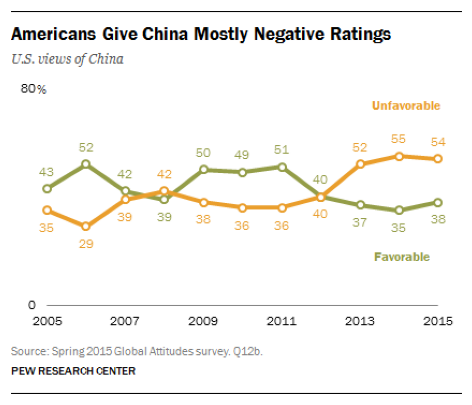

In [6]:
# Visual sanity check.
example = train_ds[0]
print("Question:", example["question"])
print("Answer:", example["answer"])
plt.figure(figsize=(8, 5))
plt.imshow(example["image"])
plt.axis("off")
plt.show()

## 3. Metrics And Answer Parsing

In [ ]:
def normalize_answer(text: Any) -> str:
    text = "" if text is None else str(text)
    text = text.strip().lower()
    text = re.sub(r"\s+", " ", text)
    text = text.strip(" .,:;\n\t")
    return text


def extract_final_answer(raw_text: str, mode: str) -> str:
    text = "" if raw_text is None else str(raw_text).strip()
    if mode == "cot":
        match = re.search(r"final\s*answer\s*:\s*(.+)", text, flags=re.IGNORECASE | re.DOTALL)
        if match:
            answer = match.group(1).strip()
            return answer.splitlines()[0].strip()
        non_empty_lines = [line.strip() for line in text.splitlines() if line.strip()]
        return non_empty_lines[-1] if non_empty_lines else ""
    return text


def exact_match(pred: str, gold: str) -> bool:
    return normalize_answer(pred) == normalize_answer(gold)


def parse_number(text: Any) -> float | None:
    if text is None:
        return None
    s = str(text).strip().lower().replace(",", "")
    percent = "%" in s or "percent" in s
    match = re.search(r"[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?", s)
    if not match:
        return None
    value = float(match.group(0))
    # Keep percentages on the same scale as written in ChartQA labels.
    return value


def numeric_match(pred: str, gold: str, tolerance: float = NUMERIC_TOLERANCE) -> bool | None:
    pred_num = parse_number(pred)
    gold_num = parse_number(gold)
    if pred_num is None or gold_num is None:
        return None
    abs_tol = tolerance
    rel_tol = tolerance * max(1.0, abs(gold_num))
    return abs(pred_num - gold_num) <= max(abs_tol, rel_tol)


def score_record(raw_pred: str, gold: str, mode: str) -> dict[str, Any]:
    pred = extract_final_answer(raw_pred, mode)
    em = exact_match(pred, gold)
    nm = numeric_match(pred, gold)
    return {
        "raw_pred": raw_pred,
        "pred": pred,
        "exact_match": em,
        "numeric_match": nm,
    }


def aggregate_metrics(records: list[dict[str, Any]]) -> dict[str, Any]:
    total = len(records)
    em = sum(bool(r["exact_match"]) for r in records) / total if total else 0.0
    numeric_records = [r for r in records if r.get("numeric_match") is not None]
    numeric_acc = (
        sum(bool(r["numeric_match"]) for r in numeric_records) / len(numeric_records)
        if numeric_records else None
    )
    return {
        "n": total,
        "exact_match": em,
        "numeric_n": len(numeric_records),
        "numeric_accuracy": numeric_acc,
    }


# Parser smoke checks.
assert extract_final_answer("Reasoning\nFinal answer: 42", "cot") == "42"
assert exact_match("  Blue ", "blue")
assert numeric_match("10.1", "10", tolerance=0.02) is True
print("Metric helpers ready.")

Metric helpers ready.


## 4. Prompts

In [ ]:
DIRECT_PROMPT = "Answer with only the final answer: a short phrase or a number. No explanation."

COT_PROMPT = """
Answer the question based on the chart.
First identify the relevant chart elements, then reason briefly if a comparison or calculation is needed.
End your response with exactly this format:
Final answer: <answer>
""".strip()

PROMPTS = {
    "direct": DIRECT_PROMPT,
    "cot": COT_PROMPT,
}

print("Direct prompt:\n", DIRECT_PROMPT)
print("\nCoT prompt:\n", COT_PROMPT)

Direct prompt:
 Answer with only the final answer: a short phrase or a number. No explanation.

CoT prompt:
 Answer the question based on the chart.
First identify the relevant chart elements, then reason briefly if a comparison or calculation is needed.
End your response with exactly this format:
Final answer: <answer>


# 5. Model Loading

In [9]:
def clear_memory() -> None:
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


def load_processor():
    return AutoProcessor.from_pretrained(MODEL_ID, trust_remote_code=True)


def load_base_model_for_inference():
    quant_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_use_double_quant=True,
        bnb_4bit_compute_dtype=torch.bfloat16,
    )
    model = Qwen3VLForConditionalGeneration.from_pretrained(
        MODEL_ID,
        quantization_config=quant_config,
        device_map="auto",
        trust_remote_code=True,
    )
    model.eval()
    return model


processor = load_processor()
model = load_base_model_for_inference()
print("Loaded", MODEL_ID)

preprocessor_config.json:   0%|          | 0.00/390 [00:00<?, ?B/s]

chat_template.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/750 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/269 [00:00<?, ?B/s]

Loaded Qwen/Qwen3-VL-8B-Instruct


## 6. Inference

In [10]:
def build_messages(image: Image.Image, question: str, mode: str) -> list[dict[str, Any]]:
    prompt = PROMPTS[mode]
    return [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": image},
                {"type": "text", "text": f"Question: {question}\n\n{prompt}"},
            ],
        }
    ]


def generate_one(model, processor, image: Image.Image, question: str, mode: str) -> str:
    messages = build_messages(image, question, mode)
    inputs = processor.apply_chat_template(
        messages,
        tokenize=True,
        add_generation_prompt=True,
        return_dict=True,
        processor_kwargs={"text_kwargs": {"return_tensors": "pt", "truncation": False}},
    )
    inputs = inputs.to(model.device)
    max_new_tokens = MAX_NEW_TOKENS_COT if mode == "cot" else MAX_NEW_TOKENS_DIRECT
    with torch.inference_mode():
        generated_ids = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
        )
    trimmed = [out_ids[len(in_ids):] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)]
    text = processor.batch_decode(trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False)[0]
    return text.strip()


def limited_len(dataset: Dataset, max_samples: int | None) -> int:
    return len(dataset) if max_samples is None else min(max_samples, len(dataset))


def iter_limited(dataset: Dataset, max_samples: int | None):
    for idx in range(limited_len(dataset, max_samples)):
        yield idx, dataset[idx]


def run_inference(
    dataset: Dataset,
    model,
    processor,
    *,
    mode: str,
    condition: str,
    split: str,
    max_samples: int | None = None,
    save: bool = True,
) -> list[dict[str, Any]]:
    records = []
    total = limited_len(dataset, max_samples)
    for idx, ex in tqdm(iter_limited(dataset, max_samples), total=total, desc=f"{condition} {split}"):
        raw_pred = generate_one(model, processor, ex["image"], ex["question"], mode)
        scored = score_record(raw_pred, ex["answer"], mode)
        records.append({
            "condition": condition,
            "split": split,
            "idx": idx,
            "imgname": ex["imgname"],
            "question": ex["question"],
            "gold": ex["answer"],
            **scored,
        })
    metrics = aggregate_metrics(records)
    print(condition, split, metrics)
    if save:
        out_path = RESULTS_DIR / f"{condition}_{split}.jsonl"
        with out_path.open("w", encoding="utf-8") as f:
            for record in records:
                f.write(json.dumps(record, ensure_ascii=False) + "\n")
        print("Saved", out_path)
    return records

## 7. Smoke Test Before Full Runs

In [11]:
smoke_direct_records = run_inference(
    val_ds, model, processor,
    mode="direct",
    condition="smoke_zero_shot_direct",
    split="val",
    max_samples=SMOKE_TEST_SAMPLES,
)
smoke_cot_records = run_inference(
    val_ds, model, processor,
    mode="cot",
    condition="smoke_zero_shot_cot",
    split="val",
    max_samples=SMOKE_TEST_SAMPLES,
)

pd.DataFrame(smoke_direct_records + smoke_cot_records)[
    ["condition", "question", "gold", "raw_pred", "pred", "exact_match", "numeric_match"]
]

smoke_zero_shot_direct val:   0%|          | 0/2 [00:00<?, ?it/s]

smoke_zero_shot_direct val {'n': 2, 'exact_match': 0.5, 'numeric_n': 1, 'numeric_accuracy': 1.0}
Saved /content/drive/MyDrive/qwen3_chartqa_outputs/results/smoke_zero_shot_direct_val.jsonl


smoke_zero_shot_cot val:   0%|          | 0/2 [00:00<?, ?it/s]

smoke_zero_shot_cot val {'n': 2, 'exact_match': 0.5, 'numeric_n': 0, 'numeric_accuracy': None}
Saved /content/drive/MyDrive/qwen3_chartqa_outputs/results/smoke_zero_shot_cot_val.jsonl


,condition,question,gold,raw_pred,pred,exact_match,numeric_match
0,smoke_zero_shot_direct,What's the color of graph with 56 as the highe...,Blue,Blue,Blue,True,None
1,smoke_zero_shot_direct,In which year the difference between blue and ...,2018,2005,2005,False,True
2,smoke_zero_shot_cot,What's the color of graph with 56 as the highe...,Blue,The line graph shows two lines: one for the U....,blue,True,None
3,smoke_zero_shot_cot,In which year the difference between blue and ...,2018,The blue line represents favorable views of Ch...,- In,False,None


## 8. Report Evaluation Setup

Report mode uses the full ChartQA human test split by default. Use the smoke-test section above for quick validation checks while iterating.

In [12]:
split_dataset = REPORT_DATASET
split_name = REPORT_SPLIT
zero_shot_max_samples = REPORT_MAX_SAMPLES

print(f"Report split: {split_name}")
print("Report examples:", limited_len(split_dataset, zero_shot_max_samples))
print("Report conditions:", ", ".join(REPORT_CONDITIONS))

Report split: test
Report examples: 1250
Report conditions: zero_shot_direct, zero_shot_cot, lora_direct, lora_cot


## 9. QLoRA Fine-Tuning

Train one answer-only adapter if `ADAPTER_DIR` is missing, otherwise reuse the saved adapter. CoT remains prompt-only during evaluation.

In [ ]:
def build_sft_messages(image: Image.Image, question: str, answer: str) -> list[dict[str, Any]]:
    return [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": image},
                {"type": "text", "text": f"Question: {question}\n\n{DIRECT_PROMPT}"},
            ],
        },
        {
            "role": "assistant",
            "content": [{"type": "text", "text": answer}],
        },
    ]


class ChartQASFTDataset(Dataset):
    def __init__(self, base_dataset: Dataset, max_samples: int | None = None):
        self.base_dataset = base_dataset
        self.n = len(base_dataset) if max_samples is None else min(max_samples, len(base_dataset))

    def __len__(self) -> int:
        return self.n

    def __getitem__(self, idx: int) -> dict[str, Any]:
        ex = self.base_dataset[idx]
        return {
            "image": ex["image"],
            "question": ex["question"],
            "answer": ex["answer"],
        }


class Qwen3VLSFTCollator:
    def __init__(self, processor):
        self.processor = processor

    def _processor_kwargs(self) -> dict[str, Any]:
        # Keep return_tensors inside processor_kwargs; top-level processor kwargs can overwrite this dict.
        return {"text_kwargs": {"padding": False, "truncation": False, "return_tensors": "pt"}}

    def __call__(self, features: list[dict[str, Any]]) -> dict[str, torch.Tensor]:
        # The planned Colab configuration uses batch size 1. Keeping this explicit
        # makes answer-token masking reliable for multimodal chat templates.
        if len(features) != 1:
            raise ValueError("Qwen3VLSFTCollator expects per_device_train_batch_size=1.")

        feature = features[0]
        full_messages = build_sft_messages(feature["image"], feature["question"], feature["answer"])
        prompt_messages = full_messages[:1]

        batch = self.processor.apply_chat_template(
            full_messages,
            tokenize=True,
            return_dict=True,
            processor_kwargs=self._processor_kwargs(),
        )
        prompt_batch = self.processor.apply_chat_template(
            prompt_messages,
            tokenize=True,
            add_generation_prompt=True,
            return_dict=True,
            processor_kwargs=self._processor_kwargs(),
        )

        labels = batch["input_ids"].clone()
        prompt_len = min(prompt_batch["input_ids"].shape[-1], labels.shape[-1])
        labels[:, :prompt_len] = -100
        if self.processor.tokenizer.pad_token_id is not None:
            labels[labels == self.processor.tokenizer.pad_token_id] = -100
        batch["labels"] = labels
        return batch


def load_model_for_qlora():
    clear_memory()
    quant_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_use_double_quant=True,
        bnb_4bit_compute_dtype=torch.bfloat16,
    )
    model = Qwen3VLForConditionalGeneration.from_pretrained(
        MODEL_ID,
        quantization_config=quant_config,
        device_map="auto",
        trust_remote_code=True,
    )
    model.config.use_cache = False
    try:
        model = prepare_model_for_kbit_training(
            model,
            gradient_checkpointing_kwargs={"use_reentrant": False},
        )
    except TypeError as exc:
        if "gradient_checkpointing_kwargs" not in str(exc):
            raise
        model = prepare_model_for_kbit_training(model)
    lora_config = LoraConfig(
        r=LORA_R,
        lora_alpha=LORA_ALPHA,
        lora_dropout=LORA_DROPOUT,
        bias="none",
        task_type="CAUSAL_LM",
        target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],
    )
    model = get_peft_model(model, lora_config)
    if hasattr(model, "enable_input_require_grads"):
        model.enable_input_require_grads()
    model.print_trainable_parameters()
    return model

In [ ]:
# Tiny training check. Run this before the full train cell if you want to validate the pipeline quickly.
RUN_TINY_TRAINING_CHECK = False

if RUN_TINY_TRAINING_CHECK:
    tiny_model = load_model_for_qlora()
    tiny_train_ds = ChartQASFTDataset(train_ds, max_samples=4)
    tiny_eval_ds = ChartQASFTDataset(val_ds, max_samples=2)
    tiny_collator = Qwen3VLSFTCollator(processor)
    tiny_dir = OUTPUT_DIR / "tiny_qlora_check"
    tiny_args = TrainingArguments(
        output_dir=str(tiny_dir),
        num_train_epochs=1,
        per_device_train_batch_size=1,
        per_device_eval_batch_size=1,
        gradient_accumulation_steps=1,
        learning_rate=LEARNING_RATE,
        logging_steps=1,
        eval_strategy="no",
        save_strategy="no",
        bf16=torch.cuda.is_available(),
        fp16=False,
        remove_unused_columns=False,
        report_to="none",
    )
    tiny_trainer = Trainer(
        model=tiny_model,
        args=tiny_args,
        train_dataset=tiny_train_ds,
        eval_dataset=tiny_eval_ds,
        data_collator=tiny_collator,
    )
    tiny_trainer.train()
    tiny_model.save_pretrained(tiny_dir)
    del tiny_trainer, tiny_model
    clear_memory()
    print("Tiny training check saved to", tiny_dir)
else:
    print("Tiny training check skipped. Set RUN_TINY_TRAINING_CHECK=True to run it.")

Tiny training check skipped. Set RUN_TINY_TRAINING_CHECK=True to run it.


In [15]:
def train_lora_adapter() -> None:
    global TRAINED_LORA_ADAPTER_THIS_SESSION
    clear_memory()
    # Drop loaded inference models before training to free GPU memory.
    for name in ["model", "model_lora", "lora_model", "trainer"]:
        if name in globals():
            del globals()[name]
    clear_memory()

    model_lora = load_model_for_qlora()
    train_sft_ds = ChartQASFTDataset(train_ds, max_samples=MAX_TRAIN_SAMPLES)
    eval_sft_ds = ChartQASFTDataset(val_ds, max_samples=MAX_EVAL_SAMPLES)

    class RuntimeQwen3VLSFTCollator:
        def __init__(self, processor):
            self.processor = processor

        def _processor_kwargs(self) -> dict[str, Any]:
            # Keep return_tensors inside processor_kwargs; top-level processor kwargs can overwrite this dict.
            return {"text_kwargs": {"padding": False, "truncation": False, "return_tensors": "pt"}}

        def __call__(self, features: list[dict[str, Any]]) -> dict[str, torch.Tensor]:
            if len(features) != 1:
                raise ValueError("RuntimeQwen3VLSFTCollator expects per_device_train_batch_size=1.")

            feature = features[0]
            full_messages = build_sft_messages(feature["image"], feature["question"], feature["answer"])
            prompt_messages = full_messages[:1]

            batch = self.processor.apply_chat_template(
                full_messages,
                tokenize=True,
                return_dict=True,
                processor_kwargs=self._processor_kwargs(),
            )
            prompt_batch = self.processor.apply_chat_template(
                prompt_messages,
                tokenize=True,
                add_generation_prompt=True,
                return_dict=True,
                processor_kwargs=self._processor_kwargs(),
            )

            labels = batch["input_ids"].clone()
            prompt_len = min(prompt_batch["input_ids"].shape[-1], labels.shape[-1])
            labels[:, :prompt_len] = -100
            if self.processor.tokenizer.pad_token_id is not None:
                labels[labels == self.processor.tokenizer.pad_token_id] = -100
            batch["labels"] = labels
            return batch

    collator = RuntimeQwen3VLSFTCollator(processor)

    training_args = TrainingArguments(
        output_dir=str(ADAPTER_DIR),
        num_train_epochs=NUM_TRAIN_EPOCHS,
        per_device_train_batch_size=TRAIN_BATCH_SIZE,
        per_device_eval_batch_size=EVAL_BATCH_SIZE,
        gradient_accumulation_steps=GRADIENT_ACCUMULATION_STEPS,
        learning_rate=LEARNING_RATE,
        logging_steps=10,
        eval_strategy="steps",
        eval_steps=100,
        save_strategy="steps",
        save_steps=100,
        save_total_limit=2,
        bf16=torch.cuda.is_available(),
        fp16=False,
        remove_unused_columns=False,
        report_to="none",
    )

    trainer = Trainer(
        model=model_lora,
        args=training_args,
        train_dataset=train_sft_ds,
        eval_dataset=eval_sft_ds,
        data_collator=collator,
    )
    trainer.train()
    ADAPTER_DIR.mkdir(parents=True, exist_ok=True)
    model_lora.save_pretrained(str(ADAPTER_DIR))
    processor.save_pretrained(str(ADAPTER_DIR))
    TRAINED_LORA_ADAPTER_THIS_SESSION = True
    print("Saved LoRA adapter to", ADAPTER_DIR)


RUN_FULL_QLORA_TRAINING = FORCE_RETRAIN_QLORA or not (ADAPTER_DIR / "adapter_config.json").is_file()

if RUN_FULL_QLORA_TRAINING:
    train_lora_adapter()
else:
    print("Reusing existing LoRA adapter at", ADAPTER_DIR)

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/750 [00:00<?, ?it/s]

trainable params: 7,667,712 || all params: 8,774,791,408 || trainable%: 0.0874


[transformers] `use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.


Step,Training Loss,Validation Loss
100,0.355525,0.347868
200,0.332443,0.323536
300,0.250600,0.320268
400,0.278934,0.319132
500,0.309022,0.304737
600,0.226068,0.293037
700,0.266116,0.289602
800,0.207989,0.286106
900,0.174105,0.286196
925,0.231976,0.286080


Saved LoRA adapter to /content/drive/MyDrive/qwen3_chartqa_outputs/qwen3_vl_8b_chartqa_lora


## 10. Report Evaluation

In [16]:
def lora_adapter_dir_ready(adapter_dir: str | Path) -> bool:
    adapter_dir = Path(adapter_dir)
    return (adapter_dir / "adapter_config.json").is_file()


def validate_lora_adapter_dir(adapter_dir: str | Path) -> Path:
    adapter_dir = Path(adapter_dir)
    config_path = adapter_dir / "adapter_config.json"
    if not config_path.is_file():
        raise FileNotFoundError(
            f"Missing LoRA adapter config: {config_path}\n"
            "Run the QLoRA training cell first, "
            "or set ADAPTER_DIR to a directory that contains adapter_config.json and adapter weights."
        )
    return adapter_dir


def load_lora_model_for_inference(adapter_dir: str | Path):
    adapter_dir = validate_lora_adapter_dir(adapter_dir)
    clear_memory()
    quant_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_use_double_quant=True,
        bnb_4bit_compute_dtype=torch.bfloat16,
    )
    base = Qwen3VLForConditionalGeneration.from_pretrained(
        MODEL_ID,
        quantization_config=quant_config,
        device_map="auto",
        trust_remote_code=True,
    )
    model = PeftModel.from_pretrained(base, str(adapter_dir))
    model.eval()
    return model


def get_base_model_for_report():
    global model
    if "model" not in globals():
        model = load_base_model_for_inference()
    model.eval()
    return model


def ensure_lora_adapter_for_report() -> Path:
    should_train = not lora_adapter_dir_ready(ADAPTER_DIR) or (
        FORCE_RETRAIN_QLORA and not TRAINED_LORA_ADAPTER_THIS_SESSION
    )
    if should_train:
        print("Training LoRA adapter for report evaluation...")
        train_lora_adapter()
    else:
        print("Using existing LoRA adapter at", ADAPTER_DIR)
    return validate_lora_adapter_dir(ADAPTER_DIR)


def run_report_evaluation(
    dataset: Dataset | None = None,
    *,
    split: str = REPORT_SPLIT,
    max_samples: int | None = REPORT_MAX_SAMPLES,
    conditions: list[str] | None = None,
) -> dict[str, list[dict[str, Any]]]:
    dataset = REPORT_DATASET if dataset is None else dataset
    conditions = REPORT_CONDITIONS if conditions is None else conditions
    condition_set = set(conditions)
    records_by_condition = {}

    if {"zero_shot_direct", "zero_shot_cot"} & condition_set:
        base_model = get_base_model_for_report()
        if "zero_shot_direct" in condition_set:
            records_by_condition["zero_shot_direct"] = run_inference(
                dataset, base_model, processor,
                mode="direct",
                condition="zero_shot_direct",
                split=split,
                max_samples=max_samples,
            )
        if "zero_shot_cot" in condition_set:
            records_by_condition["zero_shot_cot"] = run_inference(
                dataset, base_model, processor,
                mode="cot",
                condition="zero_shot_cot",
                split=split,
                max_samples=max_samples,
            )
        if "model" in globals():
            del globals()["model"]
        clear_memory()

    if {"lora_direct", "lora_cot"} & condition_set:
        adapter_dir = ensure_lora_adapter_for_report()
        for name in ["trainer", "model_lora"]:
            if name in globals():
                del globals()[name]
        clear_memory()
        lora_model = load_lora_model_for_inference(adapter_dir)
        if "lora_direct" in condition_set:
            records_by_condition["lora_direct"] = run_inference(
                dataset, lora_model, processor,
                mode="direct",
                condition="lora_direct",
                split=split,
                max_samples=max_samples,
            )
        if "lora_cot" in condition_set:
            records_by_condition["lora_cot"] = run_inference(
                dataset, lora_model, processor,
                mode="cot",
                condition="lora_cot",
                split=split,
                max_samples=max_samples,
            )
        del lora_model
        clear_memory()

    return records_by_condition


report_records = run_report_evaluation()

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/750 [00:00<?, ?it/s]

zero_shot_direct test:   0%|          | 0/1250 [00:00<?, ?it/s]

zero_shot_direct test {'n': 1250, 'exact_match': 0.6312, 'numeric_n': 869, 'numeric_accuracy': 0.7514384349827388}
Saved /content/drive/MyDrive/qwen3_chartqa_outputs/results/zero_shot_direct_test.jsonl


zero_shot_cot test:   0%|          | 0/1250 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/750 [00:00<?, ?it/s]

lora_direct test:   0%|          | 0/1250 [00:00<?, ?it/s]

lora_direct test {'n': 1250, 'exact_match': 0.7216, 'numeric_n': 871, 'numeric_accuracy': 0.7807118254879449}
Saved /content/drive/MyDrive/qwen3_chartqa_outputs/results/lora_direct_test.jsonl


lora_cot test:   0%|          | 0/1250 [00:00<?, ?it/s]

lora_cot test {'n': 1250, 'exact_match': 0.7008, 'numeric_n': 868, 'numeric_accuracy': 0.7983870967741935}
Saved /content/drive/MyDrive/qwen3_chartqa_outputs/results/lora_cot_test.jsonl


## 11. Final Metrics Table

In [17]:
def load_jsonl(path: Path) -> list[dict[str, Any]]:
    with path.open("r", encoding="utf-8") as f:
        return [json.loads(line) for line in f if line.strip()]


CONDITION_LABELS = {
    "zero_shot_direct": "Baseline / Zero-shot Direct",
    "zero_shot_cot": "Zero-shot + CoT",
    "lora_direct": "LoRA Direct",
    "lora_cot": "LoRA + CoT",
}


def dataframe_to_markdown(df: pd.DataFrame) -> str:
    if df.empty:
        return ""
    display_df = df.fillna("")
    headers = [str(col) for col in display_df.columns]
    rows = [[str(value) for value in row] for row in display_df.to_numpy()]
    lines = ["| " + " | ".join(headers) + " |"]
    lines.append("| " + " | ".join(["---"] * len(headers)) + " |")
    lines.extend("| " + " | ".join(row) + " |" for row in rows)
    return "\n".join(lines) + "\n"


def report_condition_files(split: str = REPORT_SPLIT) -> list[Path]:
    return [RESULTS_DIR / f"{condition}_{split}.jsonl" for condition in REPORT_CONDITIONS]


condition_files = report_condition_files(split_name)
all_records = []
missing_files = []
for path in condition_files:
    if path.exists():
        all_records.extend(load_jsonl(path))
    else:
        missing_files.append(path)

if missing_files:
    missing = "\n".join(str(path) for path in missing_files)
    raise FileNotFoundError(f"Missing report result files:\n{missing}\nRun run_report_evaluation() first.")

results_df = pd.DataFrame(all_records)
expected_n = limited_len(REPORT_DATASET, REPORT_MAX_SAMPLES)
row_counts = results_df.groupby("condition").size().to_dict() if not results_df.empty else {}
bad_counts = {condition: row_counts.get(condition, 0) for condition in REPORT_CONDITIONS if row_counts.get(condition, 0) != expected_n}
if bad_counts:
    raise ValueError(f"Unexpected report row counts: {bad_counts}; expected {expected_n} per condition.")

summary_rows = []
for condition in REPORT_CONDITIONS:
    group = results_df[results_df["condition"] == condition] if not results_df.empty else pd.DataFrame()
    if group.empty:
        continue
    metrics = aggregate_metrics(group.to_dict("records"))
    numeric_accuracy = metrics["numeric_accuracy"]
    summary_rows.append({
        "condition": condition,
        "label": CONDITION_LABELS.get(condition, condition),
        "split": split_name,
        "n": metrics["n"],
        "exact_match": metrics["exact_match"],
        "exact_match_percent": metrics["exact_match"] * 100,
        "numeric_n": metrics["numeric_n"],
        "numeric_accuracy": numeric_accuracy,
        "numeric_accuracy_percent": None if numeric_accuracy is None else numeric_accuracy * 100,
        "model_id": MODEL_ID,
        "adapter_path": str(ADAPTER_DIR) if condition.startswith("lora") else "",
    })

summary_df = pd.DataFrame(summary_rows)

if not results_df.empty:
    comparison_examples_df = results_df.pivot_table(
        index=["idx", "imgname", "question", "gold"],
        columns="condition",
        values="pred",
        aggfunc="first",
    ).reset_index()
    available = [condition for condition in REPORT_CONDITIONS if condition in comparison_examples_df.columns]
    comparison_examples_df = comparison_examples_df[["idx", "imgname", "question", "gold", *available]]
    report_errors_df = results_df[~results_df["exact_match"].astype(bool)].copy()
else:
    comparison_examples_df = pd.DataFrame()
    report_errors_df = pd.DataFrame()

REPORT_DIR.mkdir(parents=True, exist_ok=True)
summary_csv_path = REPORT_DIR / f"qwen3_chartqa_{split_name}_summary.csv"
summary_md_path = REPORT_DIR / f"qwen3_chartqa_{split_name}_summary.md"
examples_csv_path = REPORT_DIR / f"qwen3_chartqa_{split_name}_examples.csv"
errors_csv_path = REPORT_DIR / f"qwen3_chartqa_{split_name}_errors.csv"

summary_df.to_csv(summary_csv_path, index=False)
comparison_examples_df.to_csv(examples_csv_path, index=False)
report_errors_df.to_csv(errors_csv_path, index=False)
summary_md_path.write_text(dataframe_to_markdown(summary_df), encoding="utf-8")

print("Saved report summary CSV:", summary_csv_path)
print("Saved report summary Markdown:", summary_md_path)
print("Saved report examples CSV:", examples_csv_path)
print("Saved report errors CSV:", errors_csv_path)
summary_df

Saved report summary CSV: /content/drive/MyDrive/qwen3_chartqa_outputs/report/qwen3_chartqa_test_summary.csv
Saved report summary Markdown: /content/drive/MyDrive/qwen3_chartqa_outputs/report/qwen3_chartqa_test_summary.md
Saved report examples CSV: /content/drive/MyDrive/qwen3_chartqa_outputs/report/qwen3_chartqa_test_examples.csv
Saved report errors CSV: /content/drive/MyDrive/qwen3_chartqa_outputs/report/qwen3_chartqa_test_errors.csv


,condition,label,split,n,exact_match,exact_match_percent,numeric_n,numeric_accuracy,numeric_accuracy_percent,model_id,adapter_path
0,zero_shot_direct,Baseline / Zero-shot Direct,test,1250,0.6312,63.12,869,0.751438,75.143843,Qwen/Qwen3-VL-8B-Instruct,
1,zero_shot_cot,Zero-shot + CoT,test,1250,0.6792,67.92,850,0.852941,85.294118,Qwen/Qwen3-VL-8B-Instruct,
2,lora_direct,LoRA Direct,test,1250,0.7216,72.16,871,0.780712,78.071183,Qwen/Qwen3-VL-8B-Instruct,/content/drive/MyDrive/qwen3_chartqa_outputs/q...
3,lora_cot,LoRA + CoT,test,1250,0.7008,70.08,868,0.798387,79.838710,Qwen/Qwen3-VL-8B-Instruct,/content/drive/MyDrive/qwen3_chartqa_outputs/q...


## 12. Qualitative Error Analysis

The automatic category below is only a first pass for selecting examples. Manually review the sampled cases and refine the category in the final report.

In [18]:
def heuristic_error_category(record: dict[str, Any]) -> str:
    if record.get("exact_match"):
        return "correct"
    raw = str(record.get("raw_pred", "")).lower()
    pred = str(record.get("pred", ""))
    gold = str(record.get("gold", ""))
    if parse_number(gold) is not None and parse_number(pred) is None:
        return "formatting error"
    if parse_number(gold) is not None and parse_number(pred) is not None:
        return "arithmetic/logical error"
    if any(word in raw for word in ["axis", "label", "legend", "title"]):
        return "axis/title misread"
    if len(raw) > 300 and "final answer" not in raw:
        return "hallucinated reasoning"
    return "value extraction"


if not results_df.empty:
    analysis_df = results_df.copy()
    analysis_df["error_category"] = analysis_df.apply(lambda row: heuristic_error_category(row.to_dict()), axis=1)
    display(analysis_df[["condition", "imgname", "question", "gold", "pred", "exact_match", "numeric_match", "error_category"]].head(20))
else:
    print("No records loaded yet.")

,condition,imgname,question,gold,pred,exact_match,numeric_match,error_category
0,zero_shot_direct,test_000000.png,How many food item is shown in the bar graph?,14,14,True,True,correct
1,zero_shot_direct,test_000001.png,What is the difference in value between Lamb a...,0.57,0.57,True,True,correct
2,zero_shot_direct,test_000002.png,How many bars are shown in the chart?,3,3,True,True,correct
3,zero_shot_direct,test_000003.png,Is the sum value of Madagascar more then Fiji?,No,No,True,None,correct
4,zero_shot_direct,test_000004.png,What's the value of the lowest bar?,23,23,True,True,correct
5,zero_shot_direct,test_000005.png,What is the difference between the highest and...,6,6,True,True,correct
6,zero_shot_direct,test_000006.png,What percent who think of President Donald Tru...,62,62,True,True,correct
7,zero_shot_direct,test_000007.png,Is the sum of the percents of Charismatic and ...,Yes,No,False,None,value extraction
8,zero_shot_direct,test_000008.png,What was the 4th most popular emotion?,Inspired,Inspired,True,None,correct
9,zero_shot_direct,test_000009.png,How many more people felt inspired frequently ...,0.03,3,False,False,arithmetic/logical error


In [19]:
def show_comparison_examples(df: pd.DataFrame, max_examples: int = 10) -> None:
    if df.empty:
        print("No results to show.")
        return
    pivot = df.pivot_table(
        index=["idx", "imgname", "question", "gold"],
        columns="condition",
        values="pred",
        aggfunc="first",
    ).reset_index()
    available = [c for c in ["zero_shot_direct", "zero_shot_cot", "lora_direct", "lora_cot"] if c in pivot.columns]
    display(pivot[["imgname", "question", "gold", *available]].head(max_examples))


show_comparison_examples(results_df, max_examples=10)

condition,imgname,question,gold,zero_shot_direct,zero_shot_cot,lora_direct,lora_cot
0,test_000000.png,How many food item is shown in the bar graph?,14,14,14,15,15
1,test_000001.png,What is the difference in value between Lamb a...,0.57,0.57,0.57,0.57,0.57
2,test_000002.png,How many bars are shown in the chart?,3,3,3,3,3
3,test_000003.png,Is the sum value of Madagascar more then Fiji?,No,No,No,No,No
4,test_000004.png,What's the value of the lowest bar?,23,23,23,23,23
5,test_000005.png,What is the difference between the highest and...,6,6,6,6,6
6,test_000006.png,What percent who think of President Donald Tru...,62,62,62,62,62
7,test_000007.png,Is the sum of the percents of Charismatic and ...,Yes,No,Yes,No,Yes
8,test_000008.png,What was the 4th most popular emotion?,Inspired,Inspired,Depressed,Inspired,Inspired
9,test_000009.png,How many more people felt inspired frequently ...,0.03,3,3,3,3


## 13. Optional Colab Shutdown

Run this only after confirming the report artifacts in `outputs/report/` were saved successfully.

In [20]:
from google.colab import runtime
runtime.unassign()